<a href="https://colab.research.google.com/github/oliveira-lopes/shrimpai-pipeline/blob/main/shrimpai_pipeline_blacktophat.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SHRIMP AI - PIPELINE COM BLACK TOP HAT (TANQUE)

## Etapa 1: Configuração do Ambiente e Importação da Imagem
Nesta primeira etapa, preparamos o ambiente do Google Colab importando as bibliotecas essenciais para o nosso projeto de Processamento Digital de Imagens (PDI):
* **OpenCV (`cv2`):** Biblioteca principal para manipulação e operações morfológicas nas matrizes da imagem.
* **Matplotlib (`plt`):** Responsável por plotar os gráficos e exibir os resultados na tela.

Definimos também a função auxiliar `mostrar()`, que padroniza a exibição de imagens em tons de cinza ou coloridas (corrigindo o formato BGR nativo do OpenCV para o padrão RGB). Por fim, inicializamos o assistente de upload para carregar a imagem das pós-larvas diretamente do computador.

Ambiente pronto!


Saving Tanque.jpeg to Tanque.jpeg
Imagem: Tanque.jpeg  |  Dimensões: 1200 x 1600


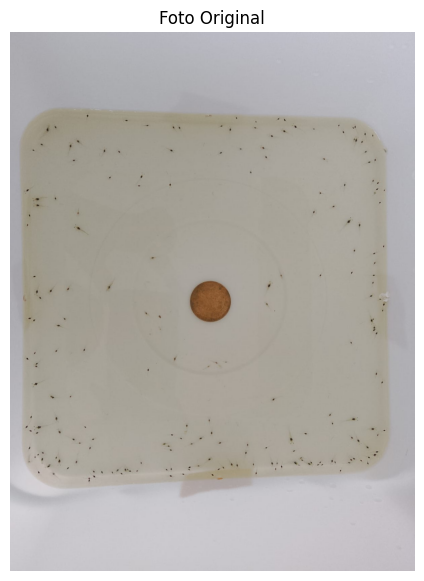

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider
from google.colab import files

plt.rcParams['figure.figsize'] = (10, 7)
plt.rcParams['image.cmap'] = 'gray'

def mostrar(img, titulo='', cmap=None):
    plt.figure()
    if img.ndim == 3:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    else:
        plt.imshow(img, cmap=cmap or 'gray')
    plt.title(titulo)
    plt.axis('off')
    plt.show()

print('Ambiente pronto!')
uploaded = files.upload()
fname = next(iter(uploaded))
bgr_original = cv2.imread(fname)
print(f'Imagem: {fname}  |  Dimensões: {bgr_original.shape[1]} x {bgr_original.shape[0]}')
mostrar(bgr_original, 'Foto Original')

## Etapa 2: Conversão para o Espaço de Cores HSV
Para isolar as características das pós-larvas, convertemos a imagem do padrão BGR original para o espaço de cores **HSV (Matiz, Saturação, Valor)**.

Para esta nova abordagem, extraímos e isolamos o **Canal V (Value / Valor)**. Como o canal V representa puramente a intensidade de brilho da imagem, ele se torna perfeito para identificar a estrutura digestiva (a barriga) das larvas, que se apresenta como pequenos pontos marcadamente escuros em relação ao tecido translúcido ao redor.

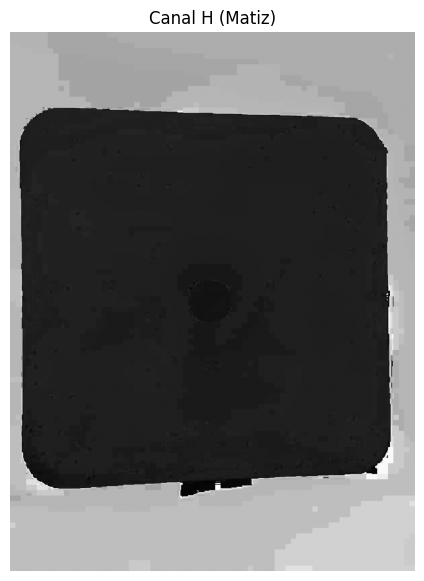

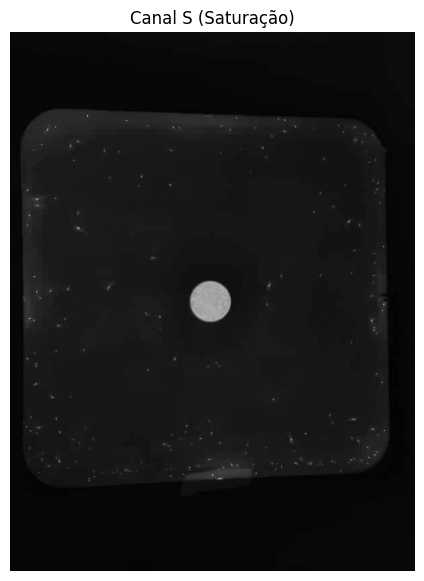

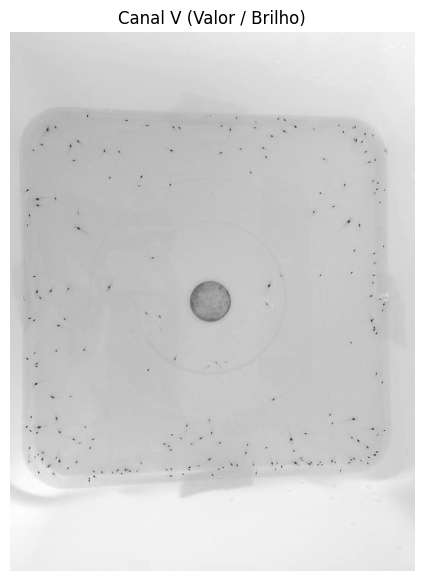

In [ ]:
# Converter a imagem original para o espaço HSV
hsv = cv2.cvtColor(bgr_original, cv2.COLOR_BGR2HSV)

# Separar os canais de forma independente
h, s, v = cv2.split(hsv)

# Exibir os canais individuais para conferência
mostrar(h, 'Canal H (Matiz)')
mostrar(s, 'Canal S (Saturação)')
mostrar(v, 'Canal V (Valor / Brilho)')

## Etapa 3: Extração de Fendas Escuras (Black Top-Hat) e Dilatação
Com o canal V isolado, aplicamos a transformação morfológica **Black Top-Hat** (ou *Bottom-Hat*). Matematicamente, ela subtrai a imagem original do seu fechamento morfológico. Na prática, funciona como um detector seletivo de vales escuros: tudo o que é mais escuro que o fundo ao redor (as barrigas) se transforma em picos brilhantes e isolados, enquanto o resto da imagem é zerado.

Logo em seguida, aplicamos uma **Dilatação** com um elemento estruturante quadrado de **$5 \times 5$**. Essa operação expande e conecta pequenas frações desses picos de luz ainda no gradiente de cinza, dando corpo e robustez aos pontos antes que eles passem pelo corte seco da binarização.

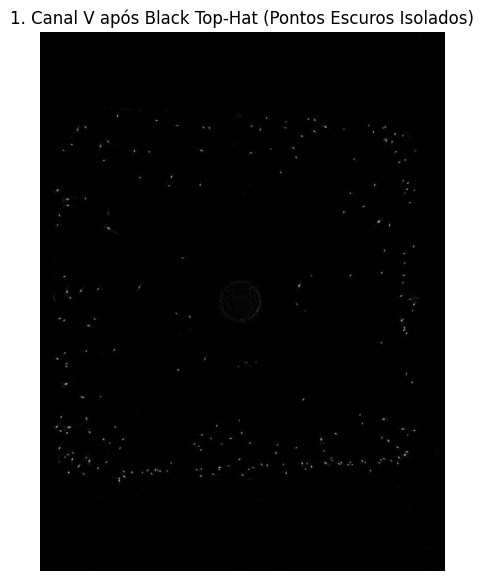

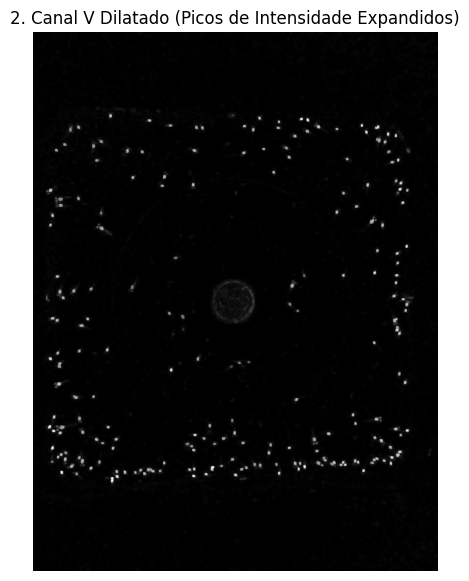

In [ ]:
# 1. Definir o kernel retangular/quadrado para o Black Top-Hat (focado em detalhes escuros pequenos)
kernel_black_hat = cv2.getStructuringElement(cv2.MORPH_RECT, (7, 7))

# 2. Definir o elemento estruturante quadrado de 5x5 para a dilatação
kernel_dilatacao = np.ones((5, 5), np.uint8)

# 3. Aplicar a transformação Black Top-Hat no canal V
v_black_hat = cv2.morphologyEx(v, cv2.MORPH_BLACKHAT, kernel_black_hat)

# 4. Aplicar a dilatação na imagem em tons de cinza resultante do Black Top-Hat
v_dilatado = cv2.dilate(v_black_hat, kernel_dilatacao, iterations=1)

# Exibir o passo a passo do realce morfológico
mostrar(v_black_hat, '1. Canal V após Black Top-Hat (Pontos Escuros Isolados)')
mostrar(v_dilatado, '2. Canal V Dilatado (Picos de Intensidade Expandidos)')

## Etapa 4: Binarização por Otsu e Filtragem de Componentes Conexas
Nesta etapa, pegamos a imagem expandida pelo processo morfológico e aplicamos a limiarização automática de **Otsu**. O algoritmo analisa o histograma e separa perfeitamente os picos de luz (pontos das larvas) em branco absoluto (255) e o fundo em preto absoluto (0).

Para realizar a contagem, mapeamos as **Componentes Conexas** da imagem binária e aplicamos um filtro de área mínima de tamanho **$X$**. Qualquer ponto residual ou ruído que possua uma área em pixels menor que $X$ é descartado, garantindo que apenas as barrigas legítimas das pós-larvas entrem na métrica final.

In [ ]:
X_otimo = 10
LARGURA_BOX = 28
ALTURA_BOX = 28
nome_base_arquivo = "lote_bandeja_01"

altura, largura, _ = bgr_original.shape
COR_AZUL_BIC = (255, 0, 0)

crop_y1, crop_y2 = int(altura * 0.14), int(altura * 0.86)
crop_x1, crop_x2 = int(largura * 0.02), int(largura * 0.98)

def analise_interativa_pontos(X=10):
    global imagem_binaria_black, X_otimo
    X_otimo = X

    limiar_black, img_otsu = cv2.threshold(v_dilatado, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(img_otsu, connectivity=8)

    imagem_binaria_black = np.zeros_like(img_otsu)
    contador = 0

    for i in range(1, num_labels):
        area = stats[i, cv2.CC_STAT_AREA]
        cx, cy = int(centroids[i][0]), int(centroids[i][1])

        if cx <= crop_x1 or cx >= crop_x2 or cy <= crop_y1 or cy >= crop_y2:
            continue

        dist_centro = np.sqrt((cx - (largura // 2))**2 + (cy - (altura // 2))**2)
        if dist_centro < 95:
            continue

        if area >= X:
            imagem_binaria_black[labels == i] = 255
            contador += 1

    print(f"--- ANÁLISE INTERATIVA DE PONTOS (BLACK HAT) ---")
    print(f"Limiar automático do Otsu: {limiar_black}")
    print(f"Objetos validados na área útil: {contador}")
    print("-" * 55)

    fig, axs = plt.subplots(1, 2, figsize=(20, 10))
    axs[0].imshow(img_otsu[crop_y1:crop_y2, crop_x1:crop_x2], cmap='gray')
    axs[0].set_title('1. Binarização Otsu Original (Com Ruído de Borda)')
    axs[0].axis('off')

    axs[1].imshow(imagem_binaria_black[crop_y1:crop_y2, crop_x1:crop_x2], cmap='gray')
    axs[1].set_title(f'2. Área Útil Filtrada (Componentes >= {X} px)')
    axs[1].axis('off')
    plt.tight_layout()
    plt.show()

interact(analise_interativa_pontos, X=IntSlider(min=0, max=50, step=1, value=10, description='Tamanho X:'));

interactive(children=(IntSlider(value=10, description='Tamanho X:', max=50), Output()), _dom_classes=('widget-…

## Etapa 5: Pipeline Final de Contagem e Auditoria Visual
Com todos os parâmetros perfeitamente ajustados e o ruído eliminado, o pipeline final consolida a contagem matemática calculando os centroides de cada ponto validado.

Para fins de auditoria e validação visual, o algoritmo desenha um **círculo laranja vazado** exatamente ao redor das coordenadas centrais ($cx, cy$) de cada barriga identificada na foto colorida original. Adicionalmente, um índice numérico azul é impresso ao lado do círculo. Isso permite conferir visualmente a precisão do sistema, garantindo que casos de sobreposição tenham sido corretamente solucionados.

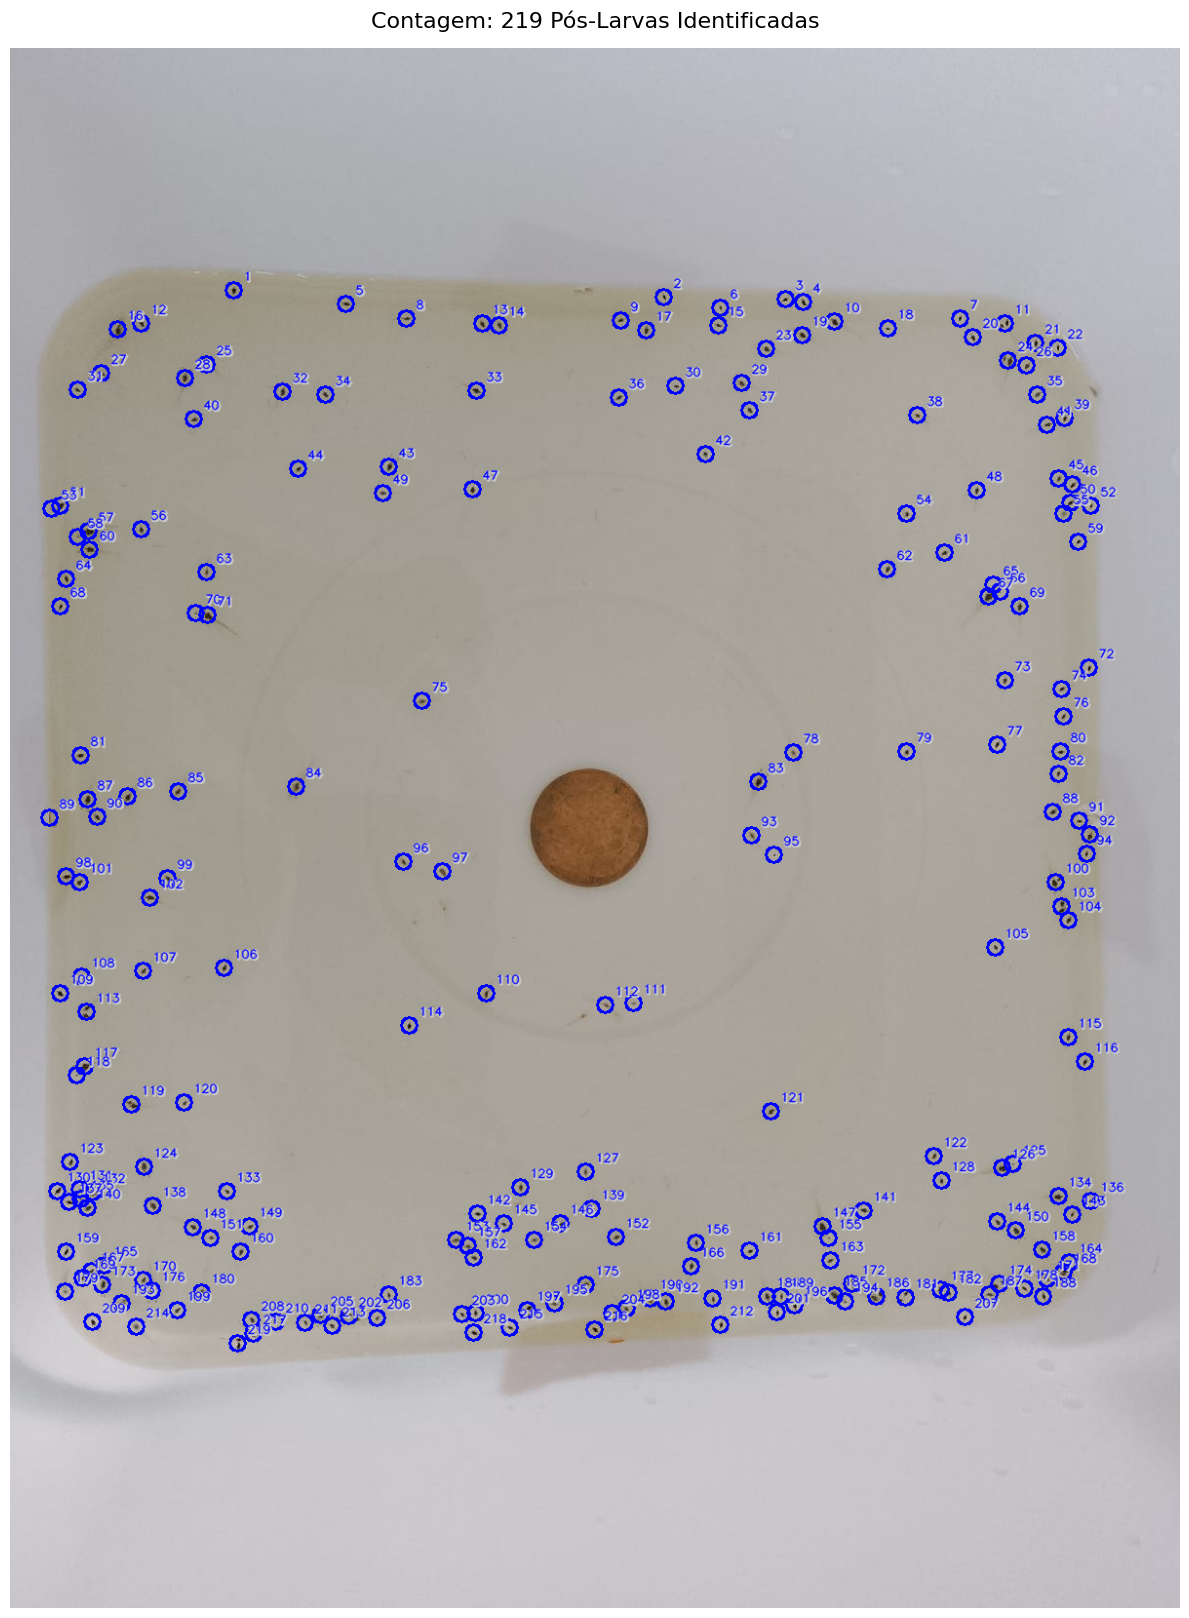

In [ ]:
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(imagem_binaria_black, connectivity=8)

bgr_resultado = bgr_original.copy()
contagem_final = 0

for i in range(1, num_labels):
    area = stats[i, cv2.CC_STAT_AREA]
    cx, cy = int(centroids[i][0]), int(centroids[i][1])

    if area > 0:
        contagem_final += 1
        cv2.circle(bgr_resultado, (cx, cy), 8, COR_AZUL_BIC, 2)

        texto_id = str(contagem_final)
        cv2.putText(bgr_resultado, texto_id, (cx + 11, cy - 9), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (200, 200, 200), 2, cv2.LINE_AA)
        cv2.putText(bgr_resultado, texto_id, (cx + 10, cy - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.4, COR_AZUL_BIC, 1, cv2.LINE_AA)

plt.figure(figsize=(12, 18))
plt.imshow(cv2.cvtColor(bgr_resultado, cv2.COLOR_BGR2RGB))
plt.title(f'Contagem: {contagem_final} Pós-Larvas Identificadas', fontsize=16, pad=15)
plt.axis('off')
plt.tight_layout()
plt.show()

# 🚧 **EM CONSTRUÇÃO!** 🚧

# Etapa 6: Geração Automatizada de Dataset para YOLO

Esta etapa utiliza a inteligência algorítmica de visão computacional desenvolvida nas células anteriores para atuar como um **rotulador automático de dados** (*Auto-Labeling*). Em vez de desenhar manualmente milhares de caixas delimitadoras (*bounding boxes*) usando softwares externos, o script aproveita os centroides validados das pós-larvas para estruturar o dataset necessário para o treinamento de redes neurais profundas (YOLO v8, v9 ou v11).

Para cada imagem processada, o pipeline exporta o par obrigatório exigido pela IA:
1. **Arquivo de Imagem (`.jpg`):** A foto original preservada, sem marcações gráficas, para servir de entrada para a rede.
2. **Arquivo de Anotação (`.txt`):** Um documento de texto com o exato mesmo nome da imagem, contendo as coordenadas normalizadas (valores entre `0.0` e `1.0`) no formato estrito da YOLO:
   `<classe_id> <x_centro> <y_centro> <largura_caixa> <altura_caixa>`

*Nota: Como o projeto foca em uma classe única, o ID da classe é fixado em `0` (pós-larva).*

✓ Dataset Gerado Corretamente: 'lote_bandeja_01.txt'
✓ Total de pós-larvas indexadas para a IA: 219


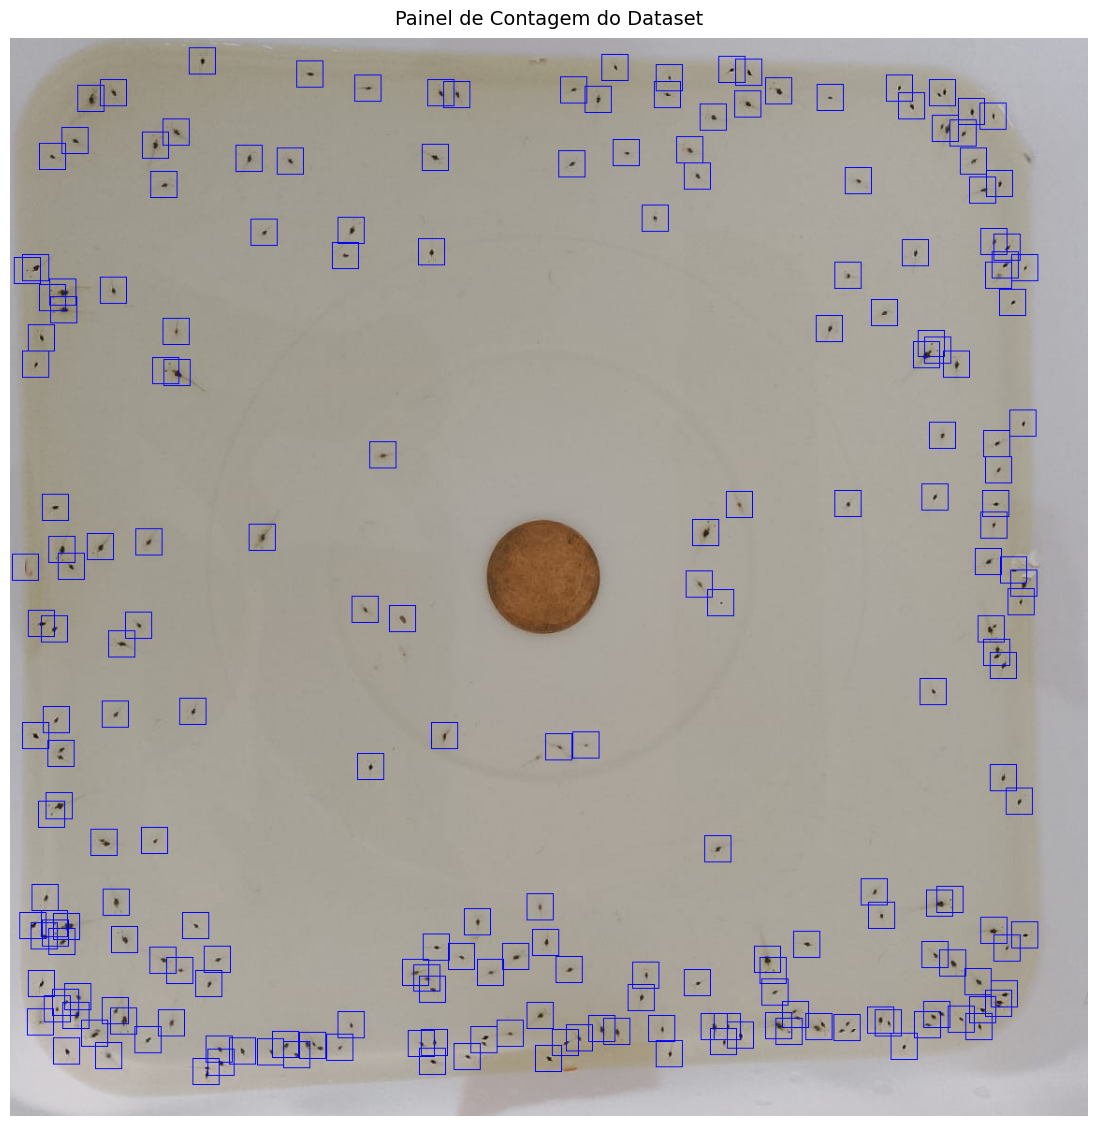

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
linhas_anotacao_yolo = []
bgr_conferencia_yolo = bgr_original.copy()

for i in range(1, num_labels):
    cx, cy = int(centroids[i][0]), int(centroids[i][1])

    if stats[i, cv2.CC_STAT_AREA] > 0:
        yolo_x = cx / largura
        yolo_y = cy / altura
        yolo_w = LARGURA_BOX / largura
        yolo_h = ALTURA_BOX / altura

        linha_yolo = f"0 {yolo_x:.6f} {yolo_y:.6f} {yolo_w:.6f} {yolo_h:.6f}\n"
        linhas_anotacao_yolo.append(linha_yolo)

        x1 = int(cx - (LARGURA_BOX / 2))
        y1 = int(cy - (ALTURA_BOX / 2))
        x2 = int(cx + (LARGURA_BOX / 2))
        y2 = int(cy + (ALTURA_BOX / 2))

        cv2.rectangle(bgr_conferencia_yolo, (x1, y1), (x2, y2), COR_AZUL_BIC, 1)

nome_txt = f"{nome_base_arquivo}.txt"
with open(nome_txt, "w") as f:
    f.writelines(linhas_anotacao_yolo)

cv2.imwrite(f"{nome_base_arquivo}.jpg", bgr_original)

print("="*60)
print(f"✓ Dataset Gerado Corretamente: '{nome_txt}'")
print(f"✓ Total de pós-larvas indexadas para a IA: {len(linhas_anotacao_yolo)}")
print("="*60)

bgr_conf_crop = bgr_conferencia_yolo[crop_y1:crop_y2, crop_x1:crop_x2]

plt.figure(figsize=(14, 14))
plt.imshow(cv2.cvtColor(bgr_conf_crop, cv2.COLOR_BGR2RGB))
plt.title("Painel de Contagem do Dataset", fontsize=14, pad=10)
plt.axis('off')
plt.show()

files.download(nome_txt)
files.download(f"{nome_base_arquivo}.jpg")

# Etapa 7: Configuração do Ambiente e Treinamento da IA (YOLO)

Nesta etapa, consolidamos a arquitetura do nosso dataset criando o arquivo de metadados obrigatório `dataset.yaml`. Esse arquivo instrui o algoritmo sobre a localização física das pastas de treino/validação e mapeia o identificador numérico `0` para o nome da nossa classe (`pos-larva`).

Após a estruturação dos diretórios, realizamos a instalação do pacote oficial da Ultralytics para iniciar o processo de treinamento por transferência de aprendizado.

In [ ]:
!pip install ultralytics -q

import os
from ultralytics import YOLO

base_dir = "/content/dataset_larvas"
os.makedirs(f"{base_dir}/images/train", exist_ok=True)
os.makedirs(f"{base_dir}/labels/train", exist_ok=True)

conteudo_yaml = f"""
path: {base_dir}
train: images/train
val: images/train
names:
  0: pos-larva
"""

caminho_yaml = "/content/dataset.yaml"
with open(caminho_yaml, "w") as f:
    f.write(conteudo_yaml.strip())

print(f"Estrutura de diretórios criada em: {base_dir}")
print(f"Arquivo de configuração criado: '{caminho_yaml}'")

Estrutura de diretórios criada em: /content/dataset_larvas
Arquivo de configuração criado: '/content/dataset.yaml'


In [ ]:
from ultralytics import YOLO

# Carrega os pesos iniciais da rede leve (Nano)
modelo = YOLO("yolov8n.pt")

# Dispara o treinamento por 50 épocas
modelo.train(data='/content/dataset.yaml', epochs=50, imgsz=640)

Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspec

FileNotFoundError: [34m[1mtrain: [0mError loading data from /content/dataset_larvas/images/train
See https://docs.ultralytics.com/datasets for dataset formatting guidance.